In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from FastBEMT.JobParameters import LowFidelityParameters
from FastBEMT.Propeller import Propeller
from FastBEMT.DataLoader import load_propeller_dict
from LFProp.Utils import get_oaspl_contour_area
import scienceplots

plt.style.use(['science', 'no-latex'])

In [6]:
# Load propeller geometry
prop_name, blade_dict = load_propeller_dict('10x7E')[0]

# Define test parameters
n_observers_per_side_range = np.array([8, 12, 16, 20, 24, 28, 32, 36, 40])
contour_size = 5

# Fixed parameters for computation
rpm = 7000
revolutions = 1
num_obs_times_per_rev = 10

print(f'Testing observer grid resolutions: {n_observers_per_side_range}')
print(f'Contour size: {contour_size} m')
print(f'Fixed parameters: rpm={rpm}, revolutions={revolutions}, num_obs_times_per_rev={num_obs_times_per_rev}')

Testing observer grid resolutions: [ 8 12 16 20 24 28 32 36 40]
Contour size: 5 m
Fixed parameters: rpm=7000, revolutions=1, num_obs_times_per_rev=10


In [7]:
# Storage for results
contour_areas = {}  # Dictionary: n_observers_per_side -> contour area (m^2)
num_observers_list = []
area_values = []

print('Running observer grid convergence analysis...')
print()

for n_obs_per_side in n_observers_per_side_range:
    # Create observer grid
    x_range = np.linspace(-contour_size, contour_size, n_obs_per_side)
    y_range = np.linspace(0, contour_size, n_obs_per_side)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X)
    r_observers = np.stack([X.flatten(), Y.flatten(), Z.flatten()], axis=1)
    
    # Create parameters
    params = LowFidelityParameters(
        rpm=rpm,
        a_inf=343,
        rho=1.225,
        mu=1.81e-5,
        n_blades=blade_dict['n_blades'],
        p_ref=2e-5,
        revolutions=revolutions,
        num_obs_times_per_rev=num_obs_times_per_rev,
        device='cuda',
    )
    
    # Create propeller
    propeller = Propeller(
        geometry=blade_dict,
        params=params,
    )
    
    # Run BEMT
    propeller.run_bemt(v_inf=0.0)
    
    # Run aeroacoustics
    propeller.run_aeroacoustics(
        observer_positions=r_observers,
        lt=1,
        i=1e-3,
        alpha_stall=15,
        keep_bpm_components=False
    )
    propeller.postprocess()
    
    # Reshape for contour calculation
    propeller.third_octave_total_oaspl = propeller.third_octave_total_oaspl.reshape(n_obs_per_side, n_obs_per_side)
    propeller.third_octave_total_oaspl = np.vstack([
        propeller.third_octave_total_oaspl[::-1, :],     # Flip for negative y
        propeller.third_octave_total_oaspl[1:, :]        # Original positive y, skip y=0 to avoid duplication
    ])
    
    # Calculate contour area
    area = get_oaspl_contour_area(propeller, target_level=60, size=contour_size, weight_below=1)
    contour_areas[n_obs_per_side] = area
    num_observers_list.append(n_obs_per_side * n_obs_per_side)
    area_values.append(area)
    
    print(f'n_observers_per_side={n_obs_per_side:2d} ({n_obs_per_side*n_obs_per_side:4d} total) -> Contour Area={area:.4f}')

print()
print('Analysis complete.')

Running observer grid convergence analysis...

[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 3.049 ms
[CUDA TIMING] BPM.__init__: 1.698 ms
[CUDA TIMING] get_observer_times: 0.986 ms
[CUDA TIMING] calculate_f1a_pressure: 6.071 ms
[CUDA TIMING] combine_sources (F1A): 1.681 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 21.230 ms
[CUDA TIMING] BPM.run_forward_bpm: 65.710 ms
[CUDA TIMING] combine_sources_bpm: 1.785 ms
n_observers_per_side= 8 (  64 total) -> Contour Area=24.9384
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 1.946 ms
[CUDA TIMING] BPM.__init__: 0.555 ms
[CUDA TIMING] get_observer_times: 0.311 ms
[CUDA TIMING] calculate_f1a_pressure: 4.170 ms
[CUDA TIMING] combine_sources (F1A): 1.076 ms
[CUDA TIMING] _perform_spectral_analysis_torch: 2.831 ms
[CUDA TIMING] BPM.run_forward_bpm: 30.684 ms
[CUDA TIMING] combine_sources_bpm: 0.084 ms
n_observers_per_side=12 ( 144 total) -> Contour Area=24.4461
[CUDA TIMING] TorchCompactAcousticSourceArray.__init__: 1.637 

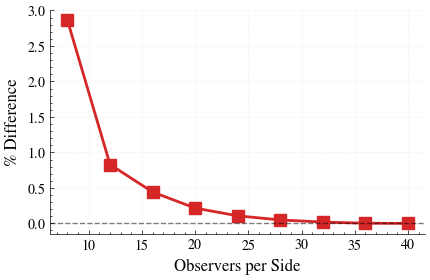

In [8]:
finest_area = area_values[-1]

relative_change = np.array([(area - finest_area) / finest_area * 100 for area in area_values])

fig, ax = plt.subplots(figsize=(4.5, 3))

ax.plot(n_observers_per_side_range, relative_change, 's-', linewidth=2, markersize=8, color='tab:red')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Observers per Side', fontsize=12)
ax.set_ylabel('% Difference', fontsize=12)
ax.grid(True, alpha=0.3, linestyle=':')

# Remove top and right spines
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(top=False, right=False, which='both')

plt.tight_layout()
plt.savefig('../Figures/observer_grid_relative_error.pdf', dpi=200)
plt.show()

In [9]:
# Summary statistics
print('='*60)
print('OBSERVER GRID CONVERGENCE SUMMARY')
print('='*60)
print(f'{"Obs/Side":<12} {"Total Obs":<15} {"Area (m²)":<15} {"Rel. Error (%)":<15}')
print('-'*60)

for i, n_obs_per_side in enumerate(n_observers_per_side_range):
    total_obs = n_obs_per_side * n_obs_per_side
    area = area_values[i]
    rel_error = relative_change[i]
    print(f'{n_obs_per_side:<12d} {total_obs:<15d} {area:<15.6f} {rel_error:<15.4f}')

print('-'*60)
print(f'Convergence achieved: {"Yes" if np.abs(relative_change[-1]) < 1.0 else "No"} (within 1% of finest grid)')

OBSERVER GRID CONVERGENCE SUMMARY
Obs/Side     Total Obs       Area (m²)       Rel. Error (%) 
------------------------------------------------------------
8            64              24.938400       2.8602         
12           144             24.446105       0.8297         
16           256             24.352156       0.4422         
20           400             24.297215       0.2156         
24           576             24.270804       0.1067         
28           784             24.256746       0.0487         
32           1024            24.249510       0.0189         
36           1296            24.245636       0.0029         
40           1600            24.244937       0.0000         
------------------------------------------------------------
Convergence achieved: Yes (within 1% of finest grid)
